In [1]:
# 1. Imports
import sys
import os
import pandas as pd
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src import data_loader, features, volatility, regimes, models_xgb, config

# 2. Multi-Sector Data Ingestion (Currently configured for XLK)
target_etf = config.TARGET_ETFS[0]
raw_data_dict = data_loader.fetch_raw_data()
raw_df = raw_data_dict[target_etf]

# 3. Engineer Features (Now with True AR Macro Surprises)
stat_df = features.engineer_stationary_features(raw_df, etf_name=target_etf)
garch_df = volatility.generate_expanding_garch(stat_df)

# 4. HMM Target Generation 
hmm_df = regimes.generate_expanding_hmm_targets(
    garch_df,
    min_window=504,
    feature_cols=['Log_Return', 'Vol_EGARCH'], 
    vol_col='Vol_EGARCH',
    n_components=3
)

# 5. Merge & Create Lags
master_df = garch_df.join(hmm_df, how='inner')
cols_to_lag = [
    'Log_Return', 'Sq_Log_Return', 'Vol_GARCH', 'Vol_EGARCH', 
    'VIX_Change', 'Oil_Change', 'CPI_Surprise', 'Unemp_Surprise', 
    'FedFunds_Diff', 'Term_Spread_Diff'
]
final_df = features.create_lags(master_df, feature_cols=cols_to_lag)

# 6. RUN THE ADVISOR'S ABLATION STUDY
print("Executing Ablation Study...")
ablation_results = models_xgb.run_ablation_study(final_df, target_col='Target_HMM')

2026-06-08 11:21:16 - src.data_loader - INFO - Processing data for XLK...


2026-06-08 11:21:17 - src.features - INFO - Engineering features and macro surprises for XLK...


2026-06-08 11:21:17 - src.features - INFO - Calculating Autoregressive Macro Surprises...


2026-06-08 11:21:17 - src.volatility - INFO - Generating Expanding GARCH & EGARCH (Window: 252, Refit: 21 days)...


2026-06-08 11:21:37 - src.volatility - INFO - Out-of-sample generation complete. Shape: (6231, 10)


...

2026-06-08 11:24:26 - src.models_xgb - INFO - Result -> Accuracy: 0.8482 | Macro F1: 0.7750


2026-06-08 11:24:26 - src.models_xgb - INFO - 
Evaluating: 2_Macro_Only (12 features)


2026-06-08 11:24:26 - src.models_xgb - INFO - Result -> Accuracy: 0.5186 | Macro F1: 0.3765


2026-06-08 11:24:26 - src.models_xgb - INFO - 
Evaluating: 3_Full_Model (27 features)


2026-06-08 11:24:28 - src.models_xgb - INFO - Result -> Accuracy: 0.8447 | Macro F1: 0.7663


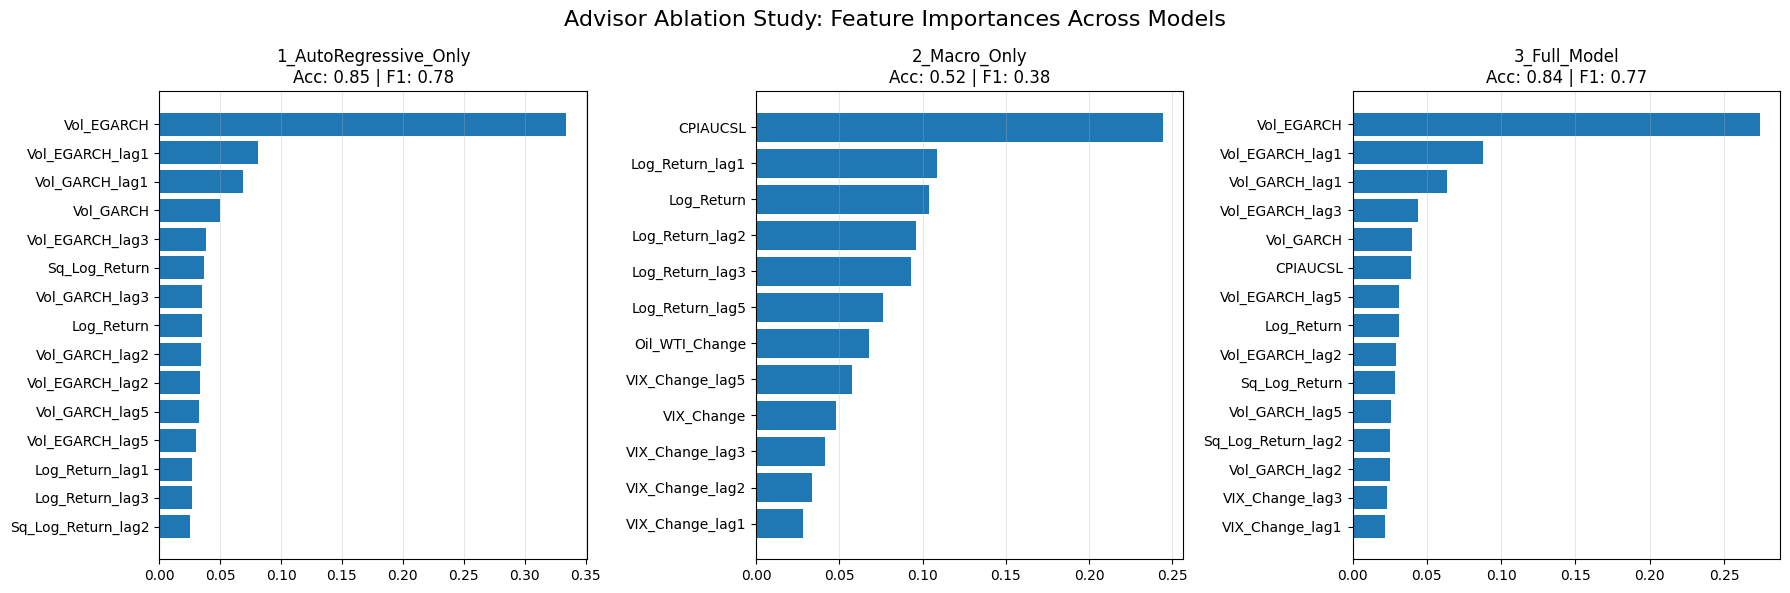

In [2]:
# 7. Visualize Proof for your Advisor
models_xgb.plot_ablation_importances(ablation_results)